# **Exercícios**

Nestes exercícios, você deve decidir qual é o gráfico visto em aula que melhor visualiza uma base de dados. Após decidir, você deverá criar a visualização usando o conteúdo exposto durante a aula e adicionar um pequeno parágrafo sobre um insights que pode ser extraido do gráfico.

## 1\. Preço do diamante por tipo de corte

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data = sns.load_dataset("diamonds")
data.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [2]:
diamonds = data[["cut","price"]].groupby("cut").agg("sum").reset_index()
diamonds.head()

C:\Users\ruben\AppData\Local\Temp\ipykernel_416\1435630458.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  diamonds = data[["cut","price"]].groupby("cut").agg("sum").reset_index()


,cut,price
0,Ideal,74513487
1,Premium,63221498
2,Very Good,48107623
3,Good,19275009
4,Fair,7017600


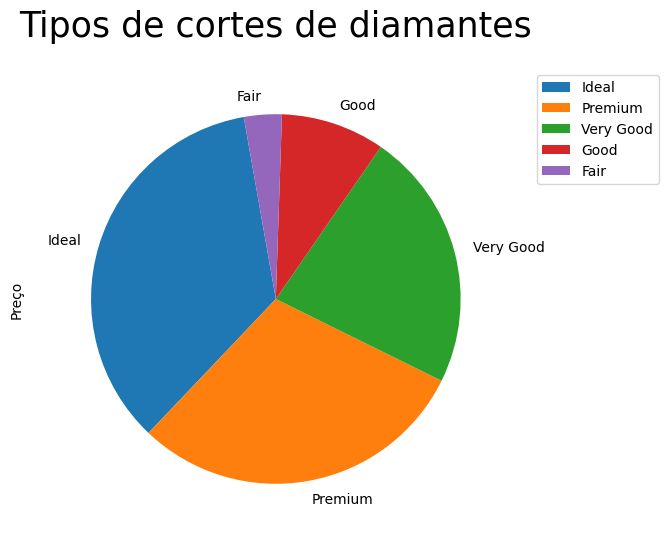

In [3]:
# gráfico do exercício 1
plt.figure(figsize=(6,6))
plt.pie(diamonds['price'], labels=diamonds['cut'], startangle=100)
plt.title("Tipos de cortes de diamantes", fontsize=25, y=1.05)
plt.legend(loc='upper left', bbox_to_anchor=(1.05,1))
plt.ylabel('Preço', labelpad=15)
plt.show()

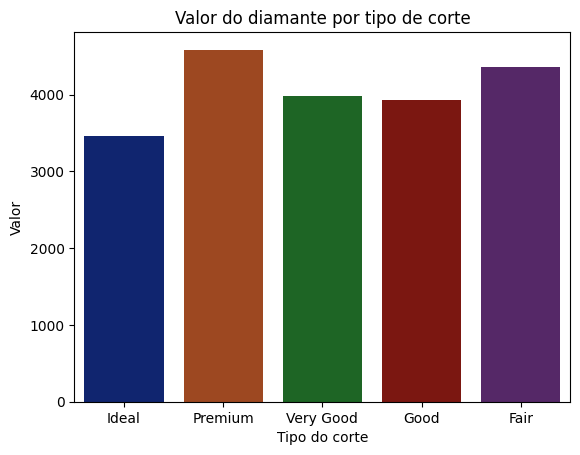

In [4]:
# Fiquei na dúvida de qual seria melhor pra visualizar emtão fiz em barras
# também

diamonds = sns.barplot(data=data, x="cut",y="price",errorbar=None,palette="dark",hue="cut")
diamonds.set(title="Valor do diamante por tipo de corte", xlabel="Tipo do corte", ylabel="Valor");

**Insight do gráfico 1**: O corte do diamante Premium sai mais.

## 2\. Número de passageiros em dezembro por ano

In [5]:
import seaborn as sns

data = sns.load_dataset("flights")
data.head()

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


In [6]:
flights = data.query('month == "Dec"')
flights = flights[["year","passengers"]].groupby("year").agg("sum").reset_index()
flights.head(20)

,year,passengers
0,1949,118
1,1950,140
2,1951,166
3,1952,194
4,1953,201
5,1954,229
6,1955,278
7,1956,306
8,1957,336
9,1958,337


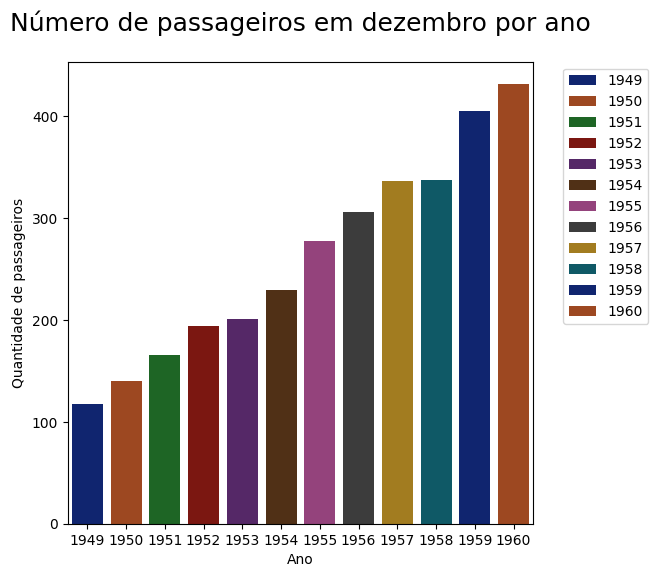

In [7]:
# gráfico do exercício 2
flights = data.query('month == "Dec"')
flights = flights[["year","passengers"]].groupby("year").agg("sum").reset_index()

plt.figure(figsize=(6,6))
flights = sns.barplot(data=flights, x="year",y="passengers",errorbar=None,palette="dark",hue="year")
flights.set(title="Número de passageiros em dezembro por ano", xlabel="Quantidade de passageiros", ylabel="Ano");
plt.title("Número de passageiros em dezembro por ano", fontsize=18, y=1.05)
plt.xlabel('Ano')
plt.ylabel('Quantidade de passageiros')
plt.legend(loc='upper left', bbox_to_anchor=(1.05,1))
plt.show()


**Insight do gráfico 2**: O número de passageiros no mês de dezembro se manteve crescendo ano após ano até ter aumento insignificante entre  1957 e 1958 e novamente continuou crescendo após esses anos até 1960, onde foi o ano com maior quantidade de passageiros no mês de dezembro.

---

## 3\. Numero de passageiros por mês entre 1949 e 1959

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

data = sns.load_dataset("flights")
data.head()

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


In [9]:
flights = data.query('1949 <= year < 1960')
flights = flights.sort_values(by='year',ascending=False)
flights.head(10)

,year,month,passengers
131,1959,Dec,405
125,1959,Jun,472
120,1959,Jan,360
121,1959,Feb,342
122,1959,Mar,406
124,1959,May,420
123,1959,Apr,396
126,1959,Jul,548
127,1959,Aug,559
128,1959,Sep,463


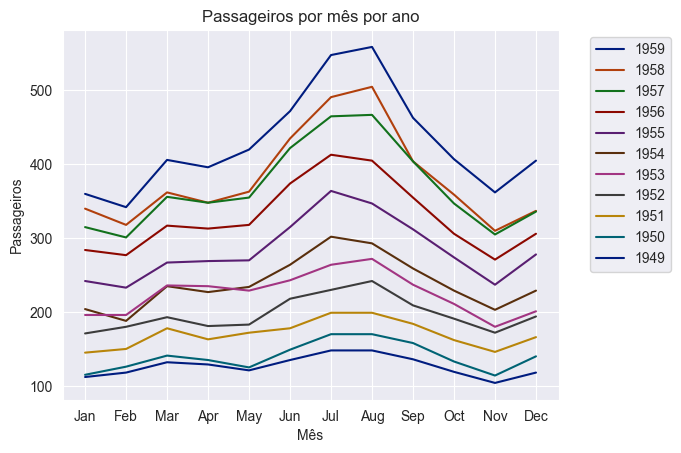

In [10]:
# gráfico do exercício 3

years = sorted(flights['year'].unique(), reverse=True)

with sns.axes_style("darkgrid"):
    grafico = sns.lineplot(data=flights, x="month", y="passengers", hue="year", hue_order=years, palette="dark")
    grafico.set(title='Passageiros por mês por ano', xlabel='Mês', ylabel='Passageiros');
    grafico.get_legend().set_title("Ano");
    plt.legend(loc='upper left', bbox_to_anchor=(1.05,1))
    plt.show()

**Insight do gráfico 3**: O ano 1959 teve maior número de passageiros durante o ano inteiro com relação aos anos anteriores. No geral, no começo em Janeiro há uma queda e de fevereiro à março um crescimento, que se mantem estável até Maio com alguns anos com uma pequena queda. A partir de Maio até Agosto sempre há um crescimento todos os anos do número de passageiros, e uma queda continua até Novembro, onde há um crescimento pequeno novamente até Janeiro.

Em todos os anos o mês com maior número de passageiros foi Agosto. Entre Março à Maio, nos anos de 1957 e 1958, o número de passageiros se manteve similar, e entre esses mesmos anos, entre Setembro à Novembro também.

Em 1953 entre Março e Abril, houve mais passageiros que o ano seguinte. Nesse mesmo ano em janeiro a quantidade de passageiro se manteve estável enquanto no ano seguinte houve uma queda pra um valor abaixo. A partir de Maio de 1954 todos os valores se mantiveram maiores que o ano anterior.

---

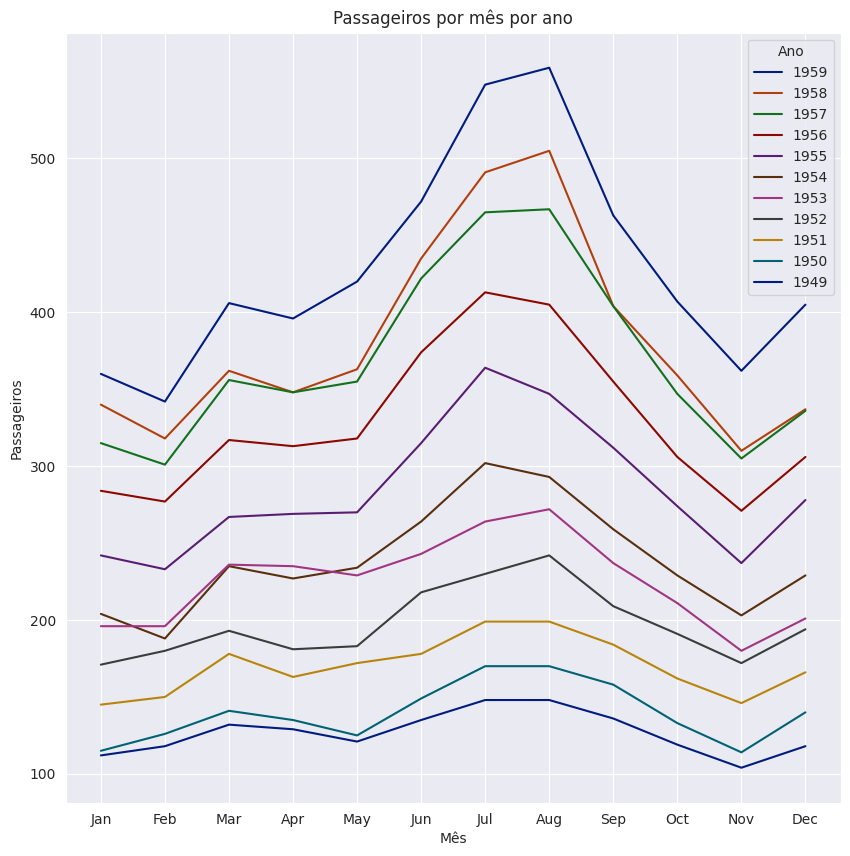

In [11]:
with sns.axes_style("darkgrid"):
    plt.figure(figsize=(10,10))
    grafico = sns.lineplot(data=flights, x="month", y="passengers", hue="year", hue_order=years, palette="dark")
    grafico.set(title='Passageiros por mês por ano', xlabel='Mês', ylabel='Passageiros');
    grafico.get_legend().set_title("Ano");